In [62]:
#Libraries
from semseg_functions import load_imgs_labels,train_model,make_predictions,load_model,run_and_visualize_layer_activation,show_filters
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import pandas as pd
import torch, cv2
from torchvision.transforms import v2
from torchvision import tv_tensors
from torch.utils.data import Dataset, DataLoader
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.ndimage as ndimage
from skimage.measure import regionprops_table, label
from skimage.morphology import binary_opening, disk, binary_closing, binary_dilation, binary_erosion,remove_small_objects
from sklearn.metrics import jaccard_score
import math
from datetime import datetime
from torch.utils.data import RandomSampler
import torchstain
import seaborn as sns
from sklearn.metrics import accuracy_score

In [63]:
"""
Loading the urothelial cell dataset and splitting it into training and validation
"""
#Load training data
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
print(urothelial_cells["X"].numpy().min())
print(urothelial_cells["X"].numpy().max())
images = urothelial_cells["X"].numpy().astype(np.float32)
print(images.min(), images.max())
labels=urothelial_cells["y"]
no_nucleus=(labels==2).sum(axis=(1,2))==0
images=images[~no_nucleus]#remove the images with no nucleus, they don't teach the model anything useful.
labels=labels[~no_nucleus]

stratify_array = labels.mean((1, 2)) >= np.median(labels.mean((1, 2)))

X_train, X_val, Y_train, Y_val = train_test_split(
    images, 
    labels, 
    test_size=0.2,          # 20% goes to validation, 80% goes to training
    stratify=stratify_array, 
    random_state=42
)

#Convert to PyTorch Tensors, model takes tensors as inputs
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
Y_train = torch.from_numpy(Y_train).long()
Y_val = torch.from_numpy(Y_val).long()



0.0
1.0
0.0 1.0


In [64]:
"""
Data augmentation step, defines tranformations to perform. 
"""

class AugmentedDataset(Dataset):
    def __init__(self, x_tensor, y_tensor, transforms=None):
        self.x = x_tensor
        self.y = y_tensor
        self.transforms = transforms

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        # Wrap mask as a tv_tensors.Mask so torchvision v2 transforms it geometrically
        lbl = tv_tensors.Mask(self.y[idx])
        
        if self.transforms:
            # Applies transforms dynamically every time a batch calls this index
            img, lbl = self.transforms(img, lbl)
            
        return img, torch.as_tensor(lbl)
        
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomApply([v2.RandomRotation(90)], p=0.5),
    v2.ColorJitter(brightness=0.15, contrast=0.15), 
    v2.RandomAdjustSharpness(sharpness_factor=2.0, p=0.5),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),   # NEW — must come last
])

# validation needs the same normalization, just no augmentation
val_transforms = v2.Compose([
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = AugmentedDataset(X_train, Y_train, transforms=train_transforms)
val_dataset = AugmentedDataset(X_val, Y_val, transforms=val_transforms)   

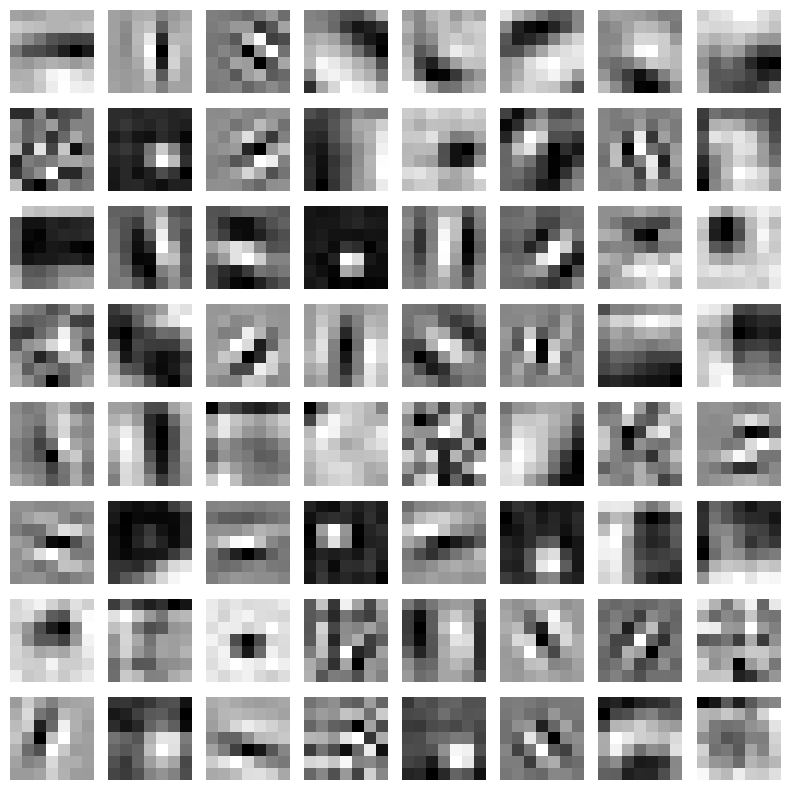

In [51]:
loaded_model = load_model(path_dir = "./seg_models/", model_key="unet", encoder_name="resnet34", device="cpu")
show_filters(loaded_model.encoder.conv1.weight)

In [53]:
model, history = train_model(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=None,
    encoder_name="resnet34", 
    model_key="unet", 
    n_epochs=30
)

Training: Epoch 1, Batch 0, Loss: 0.986
Training: Epoch 1, Batch 1, Loss: 0.837
Training: Epoch 1, Batch 2, Loss: 0.793
Training: Epoch 1, Batch 3, Loss: 0.781
Training: Epoch 1, Batch 4, Loss: 0.734
Training: Epoch 1, Batch 5, Loss: 0.669
Training: Epoch 1, Batch 6, Loss: 0.628
Training: Epoch 1, Batch 7, Loss: 0.617
Training: Epoch 1, Batch 8, Loss: 0.593
Training: Epoch 1, Batch 9, Loss: 0.55
Training: Epoch 1, Batch 10, Loss: 0.594
Training: Epoch 1, Batch 11, Loss: 0.548
Training: Epoch 1, Batch 12, Loss: 0.51
Training: Epoch 1, Batch 13, Loss: 0.466
Training: Epoch 1, Batch 14, Loss: 0.453
Training: Epoch 1, Batch 15, Loss: 0.498
Training: Epoch 1, Batch 16, Loss: 0.466
Training: Epoch 1, Batch 17, Loss: 0.456
Training: Epoch 1, Batch 18, Loss: 0.384
Val: Epoch 1, Loss: 0.476 | LR: 5e-05
Training: Epoch 2, Batch 0, Loss: 0.43
Training: Epoch 2, Batch 1, Loss: 0.376
Training: Epoch 2, Batch 2, Loss: 0.398
Training: Epoch 2, Batch 3, Loss: 0.454
Training: Epoch 2, Batch 4, Loss: 0.

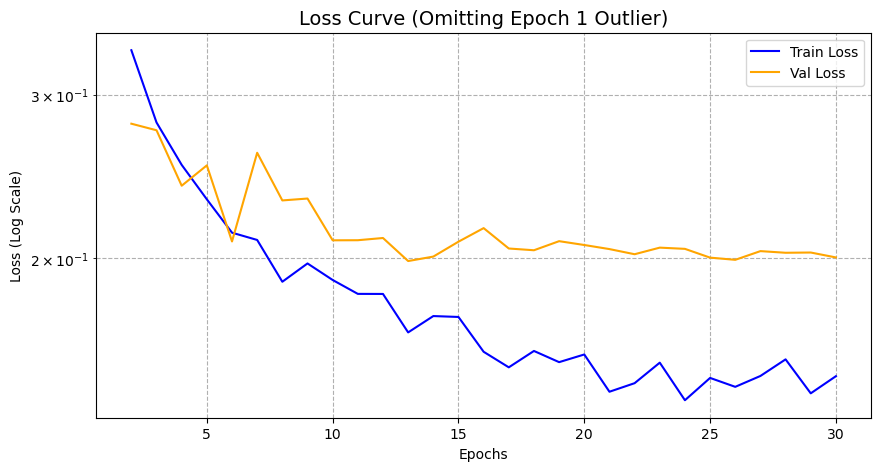

In [54]:
plt.figure(figsize=(10, 5))

plt.yscale('log')

# Skip the 1st epoch (index 0) to remove the massive outlier
epochs_to_plot = range(2, len(history['train_loss']) + 1)
plt.plot(epochs_to_plot, history['train_loss'][1:], label='Train Loss', color='blue')
plt.plot(epochs_to_plot, history['val_loss'][1:], label='Val Loss', color='orange')

plt.title('Loss Curve (Omitting Epoch 1 Outlier)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()



In [55]:
# reference - https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
filename = f"./seg_models/urothelial_unet_{current_time}_model.pkl"
torch.save(model.state_dict(), filename)

In [65]:
loaded_model = load_model(path_dir = "./seg_models/", model_key="unet", encoder_name="resnet34", device="cpu")

In [66]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
X_val_norm = (X_val - mean) / std

In [67]:
y_val_pred = make_predictions(X_val_norm, 
                              model=loaded_model, 
                              encoder_name="resnet34", 
                              model_key="unet")

In [68]:
y_val_pred_lbls = y_val_pred.argmax(1)

In [69]:
print(classification_report(Y_val.numpy().flatten(),y_val_pred_lbls.flatten()))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97    906849
           1       0.92      0.90      0.91   1087940
           2       0.85      0.90      0.87    561115

    accuracy                           0.92   2555904
   macro avg       0.91      0.92      0.92   2555904
weighted avg       0.92      0.92      0.92   2555904



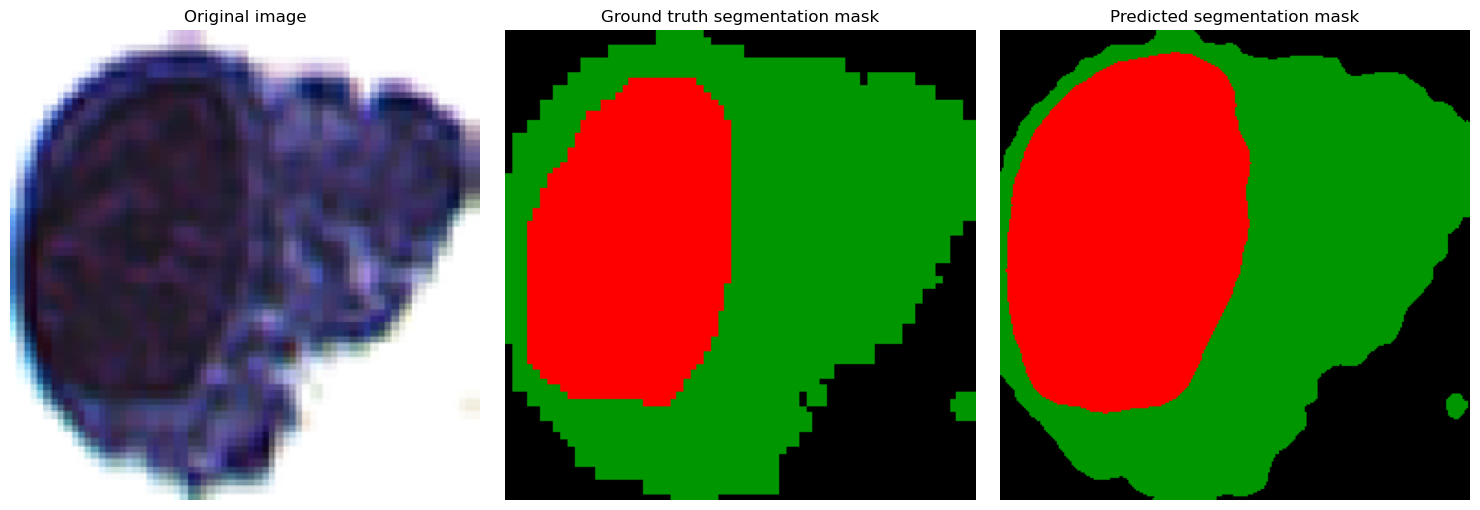

In [70]:


#index from the validation array
idx = 36
sample_mask = y_val_pred_lbls[idx]
raw_val_image = X_val[idx]    #Pulls the original image
true_val_label = Y_val[idx]   #Pulls the ground truth mask

#convert PyTorch tensors back to NumPy formats for plotting (matplotlib takes numpy inputs, not tensors)
if hasattr(raw_val_image, "numpy"):
    raw_val_image = raw_val_image.numpy()
if hasattr(true_val_label, "numpy"):
    true_val_label = true_val_label.numpy()

#Rearrange channels from PyTorch [C, H, W] to Matplotlib [H, W, C]
if raw_val_image.ndim == 3 and raw_val_image.shape[0] in [1, 3]:
    raw_val_image = np.transpose(raw_val_image, (1, 2, 0))

# Normalize the raw image decimal values to be between 0 and 1 (Data normalization)
raw_val_image = raw_val_image.astype(np.float32)
if raw_val_image.max() > 1.0:
    raw_val_image /= 255.0
"""
Post processing code
"""
#Remove nucleus noise blots
predicted_nucleus_binary = (sample_mask == 2)
cleaned_nucleus_binary = binary_opening(predicted_nucleus_binary, disk(25))
cleaned_nucleus_binary = remove_small_objects(cleaned_nucleus_binary, min_size=50)
cleaned_sample_mask = sample_mask.copy()
# Wherever your morphology code cleared a nucleus pixel, demote it back to cytoplasm (1)
cleaned_sample_mask[sample_mask == 2] = 1 
# Where the cleaned binary mask is true, explicitly set it back to nucleus (2)
cleaned_sample_mask[cleaned_nucleus_binary] = 2
# 4. Apply your defined color map to BOTH the true label and your prediction
color_map = np.array([
    [0, 0, 0],       # 0 = Background (Black)
    [0, 150, 0],     # 1 = Cytoplasm (Dark Green)
    [255, 0, 0]      # 2 = Nucleus (Bright Red)
])

"""Displaying the images using matplotlib"""
visual_predicted_mask = color_map[cleaned_sample_mask].astype(np.uint8) 
visual_true_mask = color_map[true_val_label].astype(np.uint8)

# Plot a clean, aligned 1-row by 3-column dashboard
plt.figure(figsize=(15, 5))

#far left: Original image
plt.subplot(1, 3, 1)
plt.imshow(raw_val_image)
plt.title("Original image")
plt.axis('off')

#middle image: Ground truth mask
plt.subplot(1, 3, 2)
plt.imshow(visual_true_mask)
plt.title("Ground truth segmentation mask")
plt.axis('off')

#far right: U-net output

plt.subplot(1, 3, 3)
plt.imshow(visual_predicted_mask)
plt.title("Predicted segmentation mask")
plt.axis('off')

plt.tight_layout()
plt.show()

In [72]:
"""
Feature extraction code
"""
#from the 5_DL_image_segmentation example notebook, modified slightly for my needs
"""Calculate n/c ratio"""
#true values
#counting how many times the number 2 or 1 appears in the array
nucleus_val_true = (Y_val.reshape(Y_val.shape[0], -1) == 2).sum(axis=1)
cytoplasm_val_true = (Y_val.reshape(Y_val.shape[0], -1) == 1).sum(axis=1)
nc_ratio_val_true = (nucleus_val_true / (nucleus_val_true + cytoplasm_val_true)).numpy() #array of all n/c ratios of all validation images

# Prediction values
nucleus_val_pred = (y_val_pred_lbls.reshape(y_val_pred_lbls.shape[0], -1) == 2).sum(axis=1)
cytoplasm_val_pred = (y_val_pred_lbls.reshape(y_val_pred_lbls.shape[0], -1) == 1).sum(axis=1)
nc_ratio_val_pred = nucleus_val_pred / (nucleus_val_pred + cytoplasm_val_pred)

true_nc = nc_ratio_val_true[idx] #ground truth
pred_nc = nc_ratio_val_pred[idx] #unet prediction


flat_mask = (cleaned_sample_mask == 2).astype(np.uint8)
labeled_mask = label(flat_mask) #https://scikit-image.org/docs/0.25.x/auto_examples/segmentation/plot_label.html
#properties used to calculate:  reference from 1_load_data_operations,  # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html also used as reference
PROPERTIES=['area','perimeter','convex_area','solidity'] # built in properties already calculated

props = regionprops_table(labeled_mask, properties= PROPERTIES)
extracted_features = pd.DataFrame(props)

# Calculate circularity using formula, solidity already calculated

#extracted_features['circularity'] is a pandas series (one column from the dataframe), contains indicies representing 
#the number of nuclei and their circularity values. 
#Mean() averages all of the cell's nuclei values together to create a single value to describe the cell
extracted_features['Circularity'] = 4 * (math.pi) * extracted_features['area'] / (extracted_features['perimeter'] ** 2)
circularity = extracted_features['Circularity'].mean() 


#adding other information to the table
extracted_features['Ground truth N/C ratio'] = true_nc
extracted_features['U-NET predicted n/c ratio'] = pred_nc
extracted_features['Total valid nuclei found'] = len(extracted_features)


#Flatten the arrays because jaccard_score can only compare 2 flat, linear lists.
flat_true = Y_val.numpy().flatten()
flat_pred = y_val_pred_lbls.flatten() 

# Calculate IoU for each class individually
iou_per_class = jaccard_score(flat_true, flat_pred, average=None)
mean_iou = jaccard_score(flat_true, flat_pred, average='macro')

print("Validation Dataset Iou Metrics:\n") #reference - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html
print(f"Background IoU: {iou_per_class[0]:.4f}")
print(f"Cytoplasm IoU:  {iou_per_class[1]:.4f}")
print(f"Nucleus IoU:    {iou_per_class[2]:.4f}")
print(f"Mean IoU (mIoU): {mean_iou:.4f}")

#Collapse the multiple nuclei rows into a single average row
simplified_summary = extracted_features.drop(columns=['area', 'perimeter', 'convex_area']) #remove these metrics as we don't need to know them
cell_summary = simplified_summary.mean().to_frame(name="Cell Average")

cell_summary.loc['Total valid nuclei found'] = len(extracted_features)

print("\nExtracted biomarkers:")
print(cell_summary)


Validation Dataset Iou Metrics:

Background IoU: 0.9369
Cytoplasm IoU:  0.8265
Nucleus IoU:    0.7759
Mean IoU (mIoU): 0.8464

Extracted biomarkers:
                           Cell Average
solidity                       0.984343
Circularity                    0.811738
Ground truth N/C ratio         0.334667
U-NET predicted n/c ratio      0.504227
Total valid nuclei found       1.000000
